In [1]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
!unzip "UCI HAR Dataset.zip"

--2026-04-04 21:16:16--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI HAR Dataset.zip’

UCI HAR Dataset.zip     [               <=>  ]  58.17M  16.9MB/s    in 4.2s    

2026-04-04 21:16:22 (13.7 MB/s) - ‘UCI HAR Dataset.zip’ saved [60999314]

Archive:  UCI HAR Dataset.zip
   creating: UCI HAR Dataset/
  inflating: UCI HAR Dataset/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/UCI HAR Dataset/
  inflating: __MACOSX/UCI HAR Dataset/._.DS_Store  
  inflating: UCI HAR Dataset/activity_labels.txt  
  inflating: __MACOSX/UCI HAR Dataset/._activity_labels.txt  
  inflating: UCI HAR Dataset/features.txt  
  inflating: __MACOSX/UCI HAR Dataset/._features.txt  
  inflating: UCI HAR Dataset/features_info.t

In [4]:
import numpy as np
import os

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
def load_signals(folder):
    signals = []
    files = sorted(os.listdir(folder))

    for file in files:
        data = np.loadtxt(folder + file)
        signals.append(data)

    # Convert to (samples, time_steps, features)
    return np.transpose(signals, (1, 2, 0))

# Load data
X_train = load_signals('UCI HAR Dataset/train/Inertial Signals/')
X_test = load_signals('UCI HAR Dataset/test/Inertial Signals/')

y_train = np.loadtxt('UCI HAR Dataset/train/y_train.txt') - 1
y_test = np.loadtxt('UCI HAR Dataset/test/y_test.txt') - 1

print("Train shape:", X_train.shape)  # (7352, 128, 9)
print("Test shape:", X_test.shape)    # (2947, 128, 9)

Train shape: (7352, 128, 9)
Test shape: (2947, 128, 9)


In [6]:
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(128, 9)),
    MaxPooling1D(pool_size=2),

    LSTM(100),

    Dropout(0.5),

    Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,398 (267.18 KB)

 Trainable params: 68,398 (267.18 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6073 - loss: 0.9033 - val_accuracy: 0.6939 - val_loss: 0.7111
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8396 - loss: 0.4443 - val_accuracy: 0.7893 - val_loss: 0.5883
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8904 - loss: 0.3086 - val_accuracy: 0.8337 - val_loss: 0.4196
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9276 - loss: 0.2150 - val_accuracy: 0.8775 - val_loss: 0.4340
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9319 - loss: 0.1985 - val_accuracy: 0.8711 - val_loss: 0.4092
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9389 - loss: 0.1586 - val_accuracy: 0.8782 - val_loss: 0.3288
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9450 - loss: 0.1445 - val_accuracy: 0.8863 - val_loss: 0.4089
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9510 - loss: 0.1283 - val_accuracy:

In [8]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8470 - loss: 0.5107
Test Accuracy: 0.8469629883766174


In [9]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84       496
         1.0       0.93      0.66      0.77       471
         2.0       0.76      0.99      0.86       420
         3.0       0.76      0.80      0.78       491
         4.0       0.85      0.77      0.81       532
         5.0       0.99      1.00      0.99       537

    accuracy                           0.85      2947
   macro avg       0.85      0.85      0.84      2947
weighted avg       0.85      0.85      0.84      2947



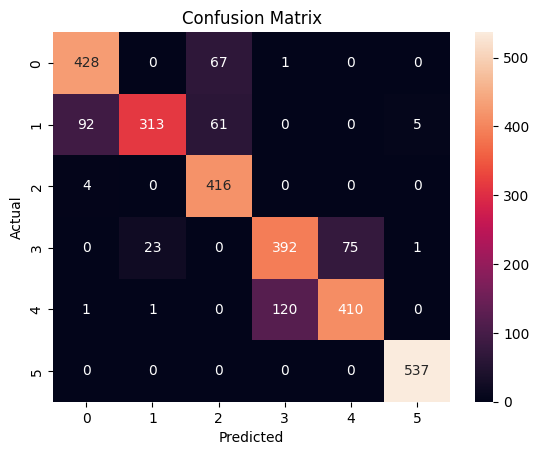

In [10]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()